In [ ]:
# importing the tensorflow and tensorflow_hub
import tensorflow as tf
import tensorflow_hub as hub
# importing some other important library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# check for GPU availability
print("GPU","available (Yessss!!!!!)" if tf.config.list_physical_devices("GPU") else "not available")

GPU not available


In [ ]:
from types import AsyncGeneratorType
# dataframe creation
import os

happy = os.listdir("/content/drive/MyDrive/archive-2/train/happy")
surprised = os.listdir("/content/drive/MyDrive/archive-2/train/surprised")
neutral = os.listdir("/content/drive/MyDrive/archive-2/train/neutral")
sad = os.listdir("/content/drive/MyDrive/archive-2/train/sad")
angry = os.listdir("/content/drive/MyDrive/archive-2/train/angry")
fear = os.listdir("/content/drive/MyDrive/archive-2/train/fearful")
disgust = os.listdir("/content/drive/MyDrive/archive-2/train/disgusted")

# they are converted into the list of the exact image path
happy_images_paths = [os.path.join("/content/drive/MyDrive/archive-2/train/happy",img) for img in happy]
surprised_images_paths = [os.path.join("/content/drive/MyDrive/archive-2/train/surprised",img) for img in surprised]
neutral_images_path = [os.path.join("/content/drive/MyDrive/archive-2/train/neutral",img) for img in neutral]
sad_images_paths = [os.path.join("/content/drive/MyDrive/archive-2/train/sad",img) for img in sad]
angry_images_paths = [os.path.join("/content/drive/MyDrive/archive-2/train/angry",img) for img in angry]
fear_images_paths = [os.path.join("/content/drive/MyDrive/archive-2/train/fearful",img) for img in fear]
disgust_images_paths = [os.path.join("/content/drive/MyDrive/archive-2/train/disgusted",img) for img in disgust]

labels = ["happy"]*len(happy_images_paths) + ["surprised"]*len(surprised_images_paths) + ["neutral"]*len(neutral_images_path) + ["sad"]*len(sad_images_paths) + ["angry"]*len(angry_images_paths) + ["fear"]*len(fear_images_paths) + ["disgust"]*len(disgust_images_paths)

data_frame = pd.DataFrame({
                           "image_path":happy_images_paths+surprised_images_paths+neutral_images_path+sad_images_paths+angry_images_paths+fear_images_paths+disgust_images_paths,
                           "labels":labels
                          })

In [ ]:
# viewing the data frame
data_frame.head()

,image_path,labels
0,/content/drive/MyDrive/archive-2/train/happy/i...,happy
1,/content/drive/MyDrive/archive-2/train/happy/i...,happy
2,/content/drive/MyDrive/archive-2/train/happy/i...,happy
3,/content/drive/MyDrive/archive-2/train/happy/i...,happy
4,/content/drive/MyDrive/archive-2/train/happy/i...,happy


In [ ]:
len(data_frame)

28714

In [ ]:
# shuffling the data frame
data_frame = data_frame.sample(frac=1)

# reseting the index
data_frame.reset_index(drop=True,inplace=True)

In [ ]:
data_frame.head(10)

,image_path,labels
0,/content/drive/MyDrive/archive-2/train/surpris...,surprised
1,/content/drive/MyDrive/archive-2/train/fearful...,fear
2,/content/drive/MyDrive/archive-2/train/fearful...,fear
3,/content/drive/MyDrive/archive-2/train/angry/i...,angry
4,/content/drive/MyDrive/archive-2/train/happy/i...,happy
5,/content/drive/MyDrive/archive-2/train/surpris...,surprised
6,/content/drive/MyDrive/archive-2/train/surpris...,surprised
7,/content/drive/MyDrive/archive-2/train/sad/im1...,sad
8,/content/drive/MyDrive/archive-2/train/angry/i...,angry
9,/content/drive/MyDrive/archive-2/train/sad/im4...,sad


In [ ]:
filenames = data_frame["image_path"]
labels = data_frame["labels"]

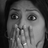

In [ ]:
from IPython.display import Image
Image(filenames[0]) # image is of 48 x 48 pixels

In [ ]:
label_counts = data_frame["labels"].value_counts()
label_counts

,count
labels,
happy,7215
neutral,4965
sad,4835
fear,4097
angry,3995
surprised,3171
disgust,436


In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Ensure we have a sorted list of unique classes for consistent indexing
class_names = np.unique(data_frame['labels'])

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=class_names,
    y=data_frame['labels']
)

# Create a dictionary mapping the class index to its weight
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("Class Weights (higher means more importance during training):")
for i, emotion in enumerate(class_names):
    print(f"{emotion} (Index {i}): {class_weight_dict[i]:.2f}")

Class Weights (higher means more importance during training):
angry (Index 0): 1.03
disgust (Index 1): 9.41
fear (Index 2): 1.00
happy (Index 3): 0.57
neutral (Index 4): 0.83
sad (Index 5): 0.85
surprised (Index 6): 1.29


<BarContainer object of 7 artists>

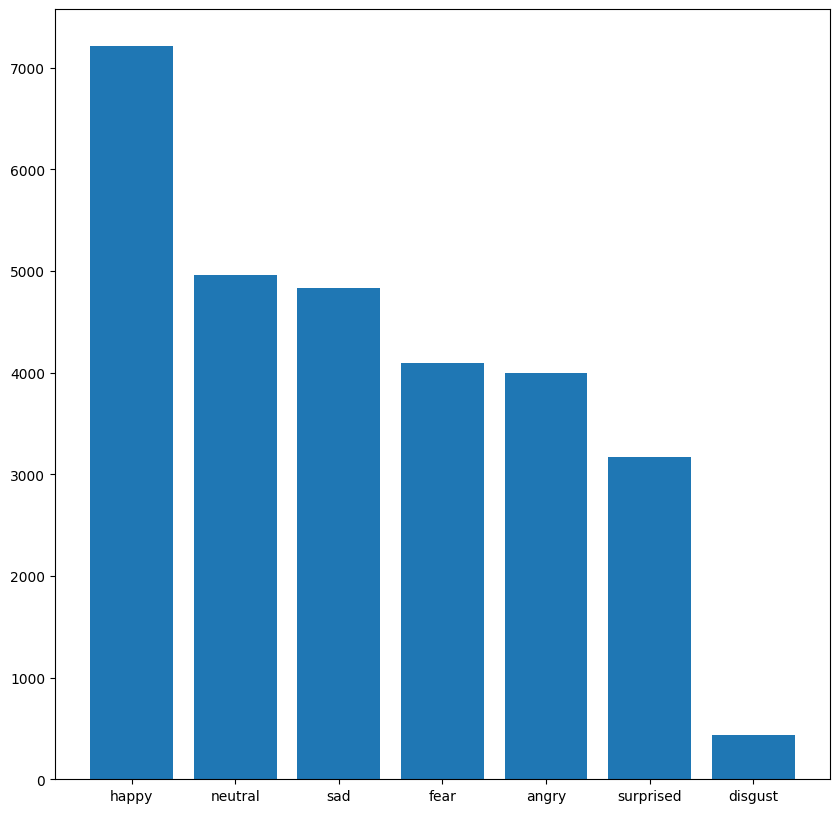

In [ ]:
fig,ax = plt.subplots(figsize=(10,10))
ax.bar(label_counts.index,label_counts.values)

In [ ]:
# There are total 7 different emotions
unique_emotions = np.unique(data_frame['labels'])

unique_emotions

array(['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprised'],
      dtype=object)

In [ ]:
boolean_label_emotions = [label == unique_emotions for label in data_frame["labels"]]
len(boolean_label_emotions)

28714

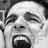

In [ ]:
Image(filenames[1])

In [ ]:
boolean_label_emotions[1]

array([False, False,  True, False, False, False, False])

In [ ]:
X = filenames
y = boolean_label_emotions

In [ ]:
# Ensuring X and y are sliced identically for 8000 samples
from sklearn.model_selection import train_test_split

# Converting to list/array to ensure slicing works correctly across different types
X_subset = X[:8000]
y_subset = y[:8000]
labels_subset = labels[:8000]

X_train, X_val, y_train, y_val = train_test_split(
    X_subset,
    y_subset,
    test_size=0.2,
    stratify=labels_subset
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Training samples: 6400
Validation samples: 1600


 As we can see that the data set for the disgust images is very low as compared to other emotions we will use the data agumentation

In [ ]:
# Image processing
IMG_SIZE = 224 # as the model which we are going to import accept this image size

def process_image(image_path):
  # reading the image
  image_data = tf.io.read_file(image_path)
  # decoding the image, forcing 3 channels (RGB)
  # FIXED: Changed decode_image_jpeg to decode_jpeg
  image = tf.image.decode_jpeg(image_data, channels=3)

  # resize the image
  image = tf.image.resize(image, size=[IMG_SIZE, IMG_SIZE])

  # normalization to [0, 1] range
  image = image / 255.0

  return image

In [ ]:
# making the function to give the image and label as tuple
def get_image_label(image_path,label):
  image = process_image(image_path)

  return image,label

In [ ]:
# creating the batches so that we can give the data to the model in the chunks
BATCH_SIZE = 32
def create_data_batches(X,y,val_data=None,test_data=None,batch_size=BATCH_SIZE):

  # creating test data batches
  if test_data:
    print("creating the test data batch")

    data = tf.data.Dataset.from_tensor_slices(tf.constant(X))
    data_batch = data.map(process_image).batch(batch_size)

    return data_batch
  # creating validation data batch
  elif val_data:
    print("creating the validation data batch")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X),tf.constant(y)))
    data_batch = data.map(get_image_label).batch(batch_size)

    return data_batch
  # creating train data batch
  else:
    print("creating the train data batch")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X),tf.constant(y)))
    data_batch = data.map(get_image_label).batch(batch_size)

    return data_batch


In [ ]:
# creating the train and validation data batch
train_data = create_data_batches(X_train,y_train)
val_data = create_data_batches(X_val,y_val,val_data=True)

creating the train data batch
creating the validation data batch


In [ ]:
INPUT_SIZE = [None,224,224,3]
OUTPUT_SIZE = len(unique_emotions)
MODEL_URL = "https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/feature_vector/4"

In [ ]:
# creating the model
import tf_keras as legacy_keras
def create_model(input_size=INPUT_SIZE,output_size=OUTPUT_SIZE,model_url=MODEL_URL):
  print("creating the model")

  # Slightly softened augmentation for better stability
  data_augmentation = legacy_keras.Sequential([
    legacy_keras.layers.RandomFlip("horizontal"),
    legacy_keras.layers.RandomRotation(0.1),
    legacy_keras.layers.RandomZoom(0.1),
], name="data_augmentation")

  model = legacy_keras.Sequential([
    legacy_keras.layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    hub.KerasLayer(model_url, trainable=True),
    # legacy_keras.layers.Dropout(0.3), # Increased dropout slightly to prevent overfitting
    legacy_keras.layers.Dense(output_size, activation="softmax")
])

  model.compile(
      loss = legacy_keras.losses.CategoricalCrossentropy(),
      # Lower learning rate for fine-tuning the whole model
      optimizer = legacy_keras.optimizers.Adam(learning_rate=1e-5),
      metrics = ["accuracy"]
               )

  model.build(input_size)

  return model

In [ ]:
model = create_model()

creating the model


In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 data_augmentation (Sequent  (None, 224, 224, 3)       0         
 ial)                                                            
                                                                 
 keras_layer (KerasLayer)    (None, 1664)              3766048   
                                                                 
 dense (Dense)               (None, 7)                 11655     
                                                                 
Total params: 3777703 (14.41 MB)
Trainable params: 3733447 (14.24 MB)
Non-trainable params: 44256 (172.88 KB)
_________________________________________________________________


In [ ]:
# creating callbacks
%load_ext tensorboard

In [ ]:
import datetime
import os

def create_tensorboard_callback():
  logdir = os.path.join("/content/drive/MyDrive/log",datetime.datetime.now().strftime("%d/%m/%Y, %H:%M:%S"))

  # Use legacy_keras.callbacks.TensorBoard for consistency with other legacy_keras imports
  tensorboard_callback = legacy_keras.callbacks.TensorBoard(logdir)

  return tensorboard_callback

In [ ]:
# creating early stopping callback
early_stopping = legacy_keras.callbacks.EarlyStopping(monitor="val_accuracy",patience=5,restore_best_weights=True) # restore_best_weights give the model with highest accuracy

In [ ]:
# creating the function to train the model
def train_model():
  model = create_model()

  tensorboard = create_tensorboard_callback()

  model.fit(
            x=train_data,
            epochs=50,
            validation_data = val_data,
            validation_freq = 1,
            callbacks=[tensorboard,early_stopping],
            class_weight=class_weight_dict
           )
  return model

In [ ]:
model = train_model()

creating the model
Epoch 1/50
200/200 [==============================] - 1388s 7s/step - loss: 2.0593 - accuracy: 0.1663 - val_loss: 2.1924 - val_accuracy: 0.1456
Epoch 2/50
200/200 [==============================] - 42s 209ms/step - loss: 1.8568 - accuracy: 0.2586 - val_loss: 1.9318 - val_accuracy: 0.2494
Epoch 3/50
200/200 [==============================] - 42s 212ms/step - loss: 1.7466 - accuracy: 0.3233 - val_loss: 1.8126 - val_accuracy: 0.3306
Epoch 4/50
200/200 [==============================] - 44s 217ms/step - loss: 1.6746 - accuracy: 0.3647 - val_loss: 1.7109 - val_accuracy: 0.3862
Epoch 5/50
200/200 [==============================] - 48s 238ms/step - loss: 1.6081 - accuracy: 0.3920 - val_loss: 1.6416 - val_accuracy: 0.4106
Epoch 6/50
200/200 [==============================] - 44s 219ms/step - loss: 1.5386 - accuracy: 0.4112 - val_loss: 1.6209 - val_accuracy: 0.4187
Epoch 7/50
200/200 [==============================] - 43s 214ms/step - loss: 1.4922 - accuracy: 0.4416 - val_los

In [ ]:
# Saving the model
model.save("/content/drive/MyDrive/emotion_detection_model.h5")
print("Model saved!")

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved!


In [ ]:
# loading the model
loaded_model = legacy_keras.models.load_model(
    "/content/drive/MyDrive/emotion_detection_model.h5",
    custom_objects={"KerasLayer": hub.KerasLayer}
)
print("model loaded")

model loaded


# Model Evaluation

In [ ]:
# creating the test data ready for model evaluation
happy = os.listdir("/content/drive/MyDrive/archive-2/test/happy")
surprised = os.listdir("/content/drive/MyDrive/archive-2/test/surprised")
neutral = os.listdir("/content/drive/MyDrive/archive-2/test/neutral")
sad = os.listdir("/content/drive/MyDrive/archive-2/test/sad")
angry = os.listdir("/content/drive/MyDrive/archive-2/test/angry")
fear = os.listdir("/content/drive/MyDrive/archive-2/test/fearful")
disgust = os.listdir("/content/drive/MyDrive/archive-2/test/disgusted")

# they are converted into the list of the exact image path
happy_images_paths = [os.path.join("/content/drive/MyDrive/archive-2/train/happy",img) for img in happy]
surprised_images_paths = [os.path.join("/content/drive/MyDrive/archive-2/test/surprised",img) for img in surprised]
neutral_images_path = [os.path.join("/content/drive/MyDrive/archive-2/test/neutral",img) for img in neutral]
sad_images_paths = [os.path.join("/content/drive/MyDrive/archive-2/test/sad",img) for img in sad]
angry_images_paths = [os.path.join("/content/drive/MyDrive/archive-2/test/angry",img) for img in angry]
fear_images_paths = [os.path.join("/content/drive/MyDrive/archive-2/test/fearful",img) for img in fear]
disgust_images_paths = [os.path.join("/content/drive/MyDrive/archive-2/test/disgusted",img) for img in disgust]


test_data = pd.DataFrame({
                           "image_path":happy_images_paths+surprised_images_paths+neutral_images_path+sad_images_paths+angry_images_paths+fear_images_paths+disgust_images_paths,
                        })

test_data

,image_path
0,/content/drive/MyDrive/archive-2/train/happy/i...
1,/content/drive/MyDrive/archive-2/train/happy/i...
2,/content/drive/MyDrive/archive-2/train/happy/i...
3,/content/drive/MyDrive/archive-2/train/happy/i...
4,/content/drive/MyDrive/archive-2/train/happy/i...
...,...
7173,/content/drive/MyDrive/archive-2/test/disguste...
7174,/content/drive/MyDrive/archive-2/test/disguste...
7175,/content/drive/MyDrive/archive-2/test/disguste...
7176,/content/drive/MyDrive/archive-2/test/disguste...


In [ ]:
len(test_data)

7178

In [ ]:
# shuffling the test data
test_data = test_data.sample(frac=1).reset_index(drop=True)
test_data

,image_path
0,/content/drive/MyDrive/archive-2/test/surprise...
1,/content/drive/MyDrive/archive-2/test/sad/im12...
2,/content/drive/MyDrive/archive-2/test/sad/im86...
3,/content/drive/MyDrive/archive-2/train/happy/i...
4,/content/drive/MyDrive/archive-2/test/sad/im22...
...,...
7173,/content/drive/MyDrive/archive-2/train/happy/i...
7174,/content/drive/MyDrive/archive-2/train/happy/i...
7175,/content/drive/MyDrive/archive-2/test/neutral/...
7176,/content/drive/MyDrive/archive-2/train/happy/i...


In [ ]:
filenames_test = test_data["image_path"]

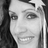

In [ ]:
Image(filenames_test[100])

In [ ]:
filenames_test[100]

'/content/drive/MyDrive/archive-2/train/happy/im873.png'

In [ ]:
# Pass None for 'y' to satisfy the positional argument requirement
test_image = create_data_batches([filenames_test[100]], y=None, test_data=True)
predictions = loaded_model.predict(test_image)
predictions

creating the test data batch
1/1 [==============================] - 0s 253ms/step


array([[1.1771066e-03, 2.7179508e-03, 4.2934828e-03, 9.8145479e-01,
        8.3455915e-04, 2.7364583e-04, 9.2484467e-03]], dtype=float32)

In [ ]:
unique_emotions[np.argmax(predictions)]

'happy'

In [ ]:
predictions[0][np.argmax(predictions)]

np.float32(0.9814548)

In [ ]:
# creating the function for all this(predicting the emotion)
def predict_emotion(image_path):
    image = create_data_batches([image_path], y=None, test_data=True)
    predictions = loaded_model.predict(image)
    predicted_emotion = unique_emotions[np.argmax(predictions)]
    print(predicted_emotion)

In [ ]:
predict_emotion(filenames_test[4])

creating the test data batch
1/1 [==============================] - 0s 119ms/step
sad


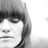

In [ ]:
Image(filenames_test[4])